# QFT with Cards Shuffling

___

This example will illustrate with a deck of playing cards how the QFT can find a period inside a pattern (here a shuffling).

In [1]:
import random
from itertools import product
from fractions import Fraction
import logging
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UnitaryGate, QFTGate
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import manim as mn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

mn.config.media_width = "75%"
mn.config.verbosity = "ERROR"

logging.getLogger('qiskit').setLevel(logging.ERROR)
logging.getLogger('qiskit.transpiler').setLevel(logging.ERROR)

In [2]:
# Create a cards list (+1 because the first card never moves)
n_cards = 26
cards_numbers = [str(n) for n in list(range(2, 11))] + ["J", "Q", 'K', "A"]
cards_suits = ["D", "S", "H", "C"]
cards_deck = [""] + ["_".join(pair[::-1]) for pair in list(product(cards_suits, cards_numbers))]
cards_deck = (cards_deck * (n_cards//52+1))[:n_cards+1]
print(cards_deck)
print(len(cards_deck))

['', '2_D', '3_D', '4_D', '5_D', '6_D', '7_D', '8_D', '9_D', '10_D', 'J_D', 'Q_D', 'K_D', 'A_D', '2_S', '3_S', '4_S', '5_S', '6_S', '7_S', '8_S', '9_S', '10_S', 'J_S', 'Q_S', 'K_S', 'A_S']
27


Manim Community v0.20.1

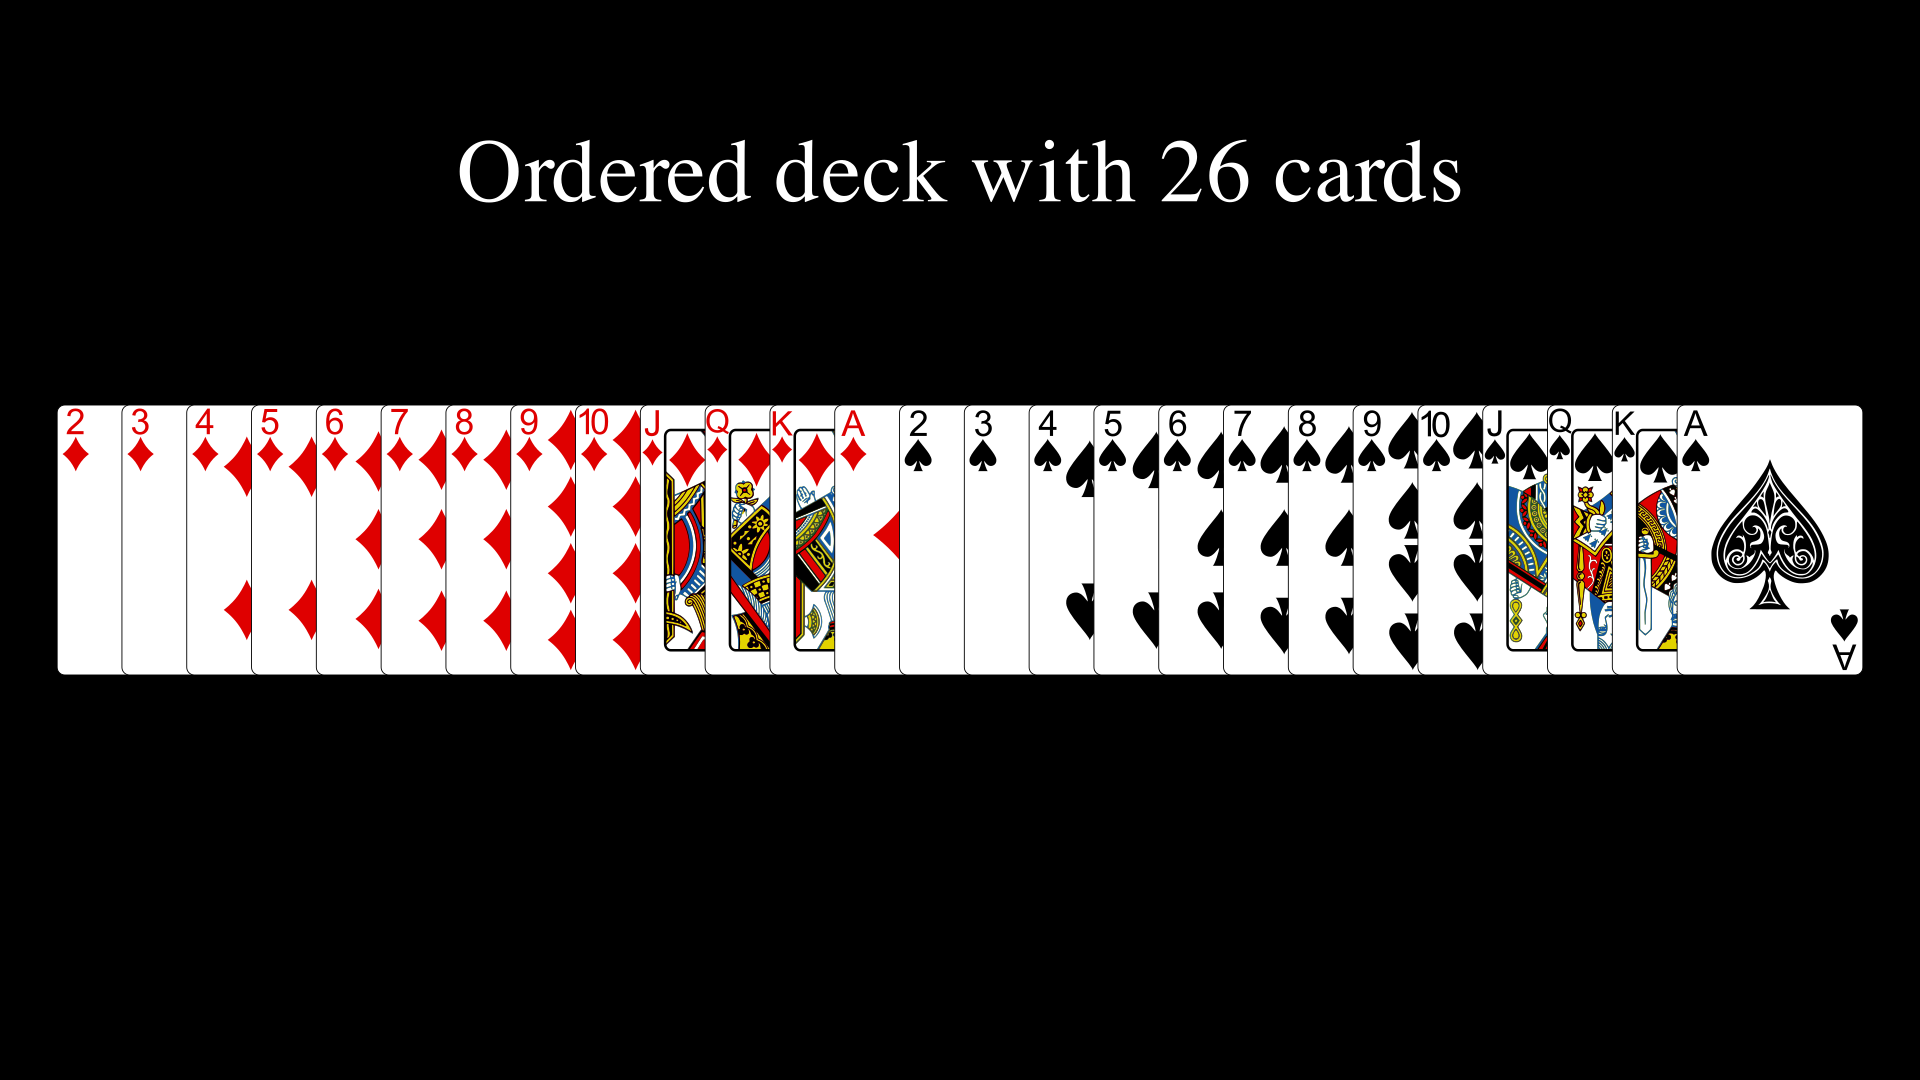

In [3]:
%%manim -qh ShowCards
class ShowCards(mn.Scene):
    def construct(self):
        x_min, x_max = -6, 6
        cards_positions = np.linspace(x_min, x_max, n_cards)

        cards = mn.VGroup()

        for n, pos in enumerate(cards_positions):
            card = mn.SVGMobject(f"images/cards/{cards_deck[n+1]}.svg")
            card.move_to([pos, 0, 0])
            cards.add(card)

        self.add(cards)

        label = mn.Text(f"Ordered deck with {n_cards} cards")
        label.next_to(cards, mn.UP, buff=1.5)
        self.add(label)

In [4]:
# Create a shuffling process (modular multiplication) based on the number of cards
def deck_shuffling_matrix(N):
    # Choose a random a such that gcd(a, N) = 1
    possible_as = list(range(2, N-2))
    random.shuffle(possible_as)
    for a in possible_as:
        if np.gcd(a, N) == 1:
            break
    # Modular multiplication M(a, N)
    M = np.zeros((N,N))
    for i in range(N):
        for j in range(N):
            if (a*j)%N==i:
                M[i][j] = 1
    return M

# Calculate how many shuffle queries it would take to measure the period classically vs quantum-ly
for N in range(5, 60):
    print()
    print("N =", N)
    base_state = list(range(N))
    lowest_r = np.inf
    U = deck_shuffling_matrix(N)
    total_qubits = 3 * int(np.ceil(np.log2(N)))
    for i in range(1000):
        for r in range(1, N):
            if (np.linalg.matrix_power(U, r)@base_state == base_state).all():
                if r < lowest_r:
                    lowest_r = r
                break
    print(f"Classical shuffle queries = {lowest_r} / Quantum shuffle queries = {int(np.ceil(np.log2(N+1)))} ({total_qubits} qubits)")


N = 5
Classical shuffle queries = 4 / Quantum shuffle queries = 3 (9 qubits)

N = 6
Classical shuffle queries = inf / Quantum shuffle queries = 3 (9 qubits)

N = 7
Classical shuffle queries = 3 / Quantum shuffle queries = 3 (9 qubits)

N = 8
Classical shuffle queries = 2 / Quantum shuffle queries = 4 (9 qubits)

N = 9
Classical shuffle queries = 6 / Quantum shuffle queries = 4 (12 qubits)

N = 10
Classical shuffle queries = 4 / Quantum shuffle queries = 4 (12 qubits)

N = 11
Classical shuffle queries = 5 / Quantum shuffle queries = 4 (12 qubits)

N = 12
Classical shuffle queries = 2 / Quantum shuffle queries = 4 (12 qubits)

N = 13
Classical shuffle queries = 12 / Quantum shuffle queries = 4 (12 qubits)

N = 14
Classical shuffle queries = 3 / Quantum shuffle queries = 4 (12 qubits)

N = 15
Classical shuffle queries = 4 / Quantum shuffle queries = 4 (12 qubits)

N = 16
Classical shuffle queries = 4 / Quantum shuffle queries = 5 (12 qubits)

N = 17
Classical shuffle queries = 16 / Quant

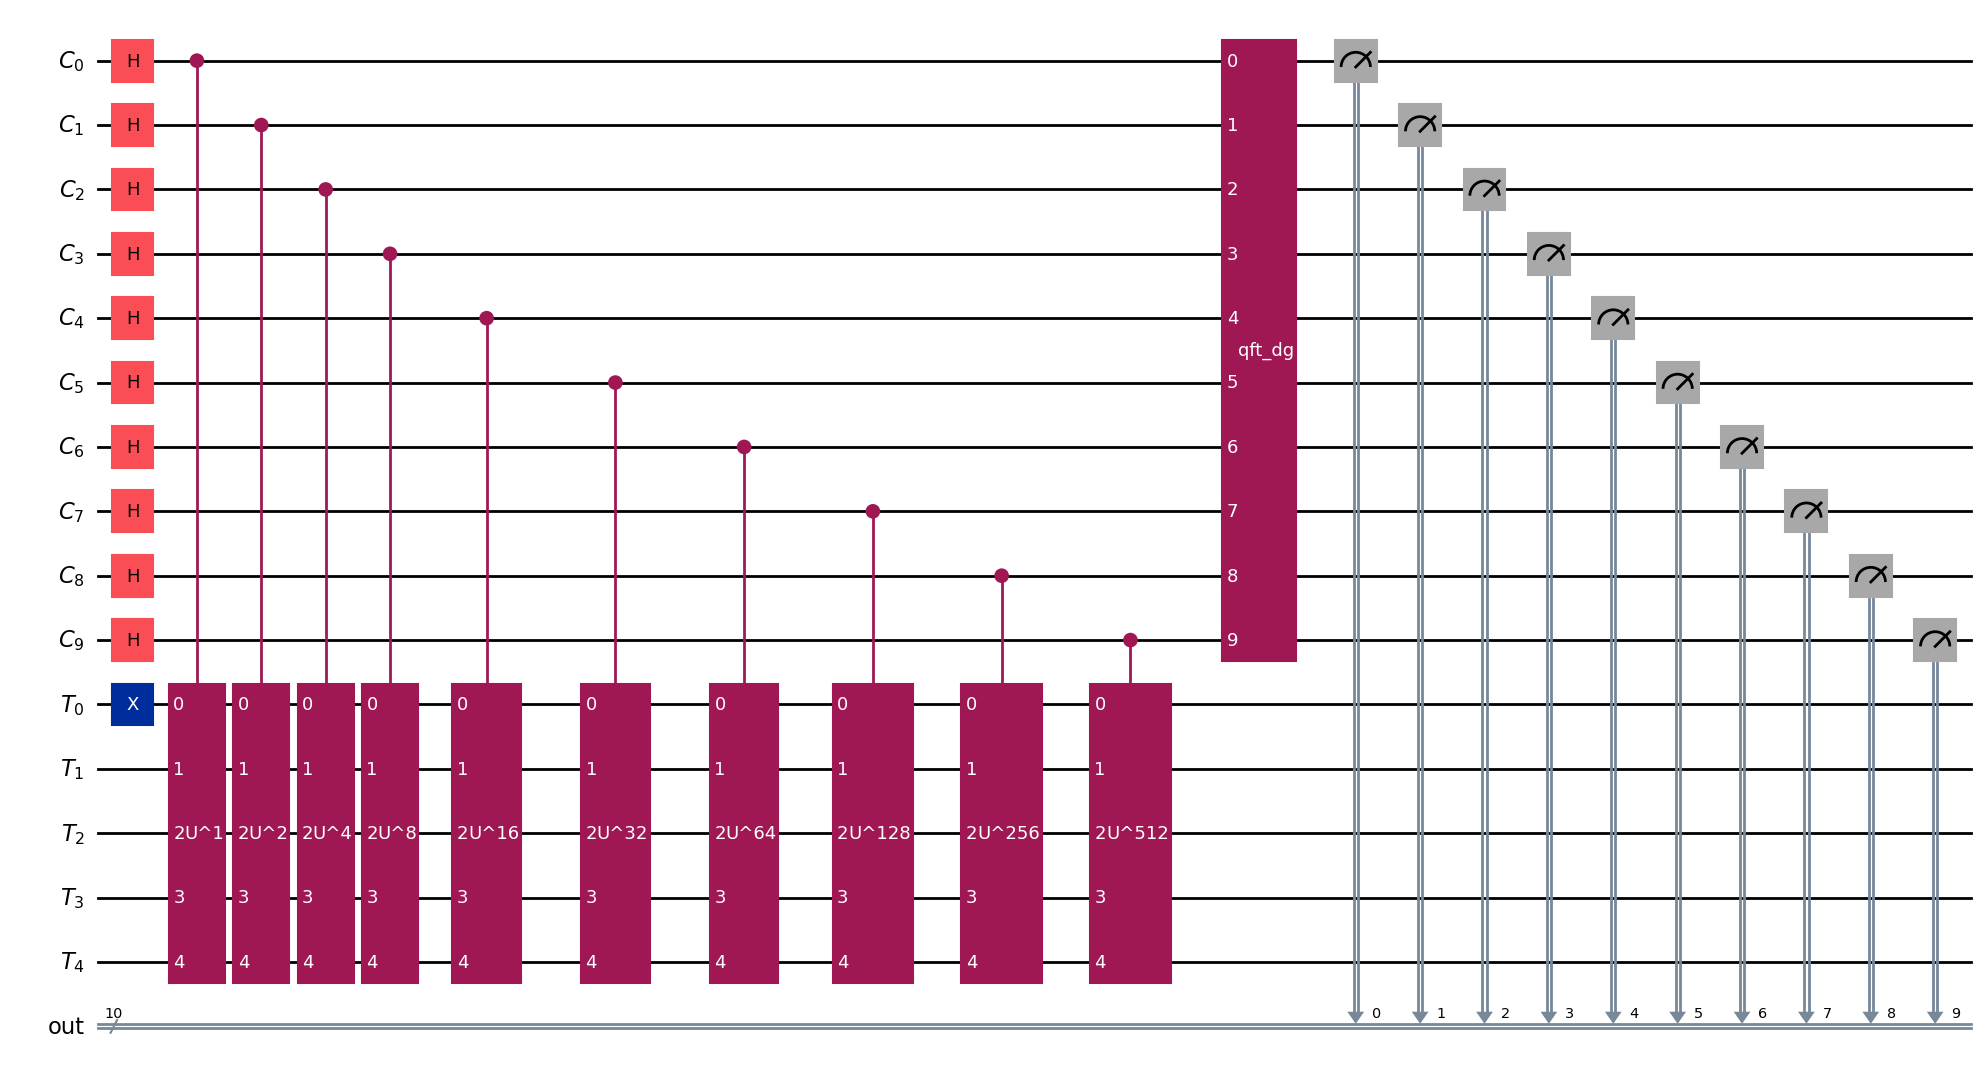

In [5]:
# Build the quantum circuit
N = n_cards+1
M = deck_shuffling_matrix(N)

# Circuit
n_target_qubits = int(np.ceil(np.log2(N)))
n_control_qubits = 2*n_target_qubits

control_register = QuantumRegister(n_control_qubits, name="C")
target_register = QuantumRegister(n_target_qubits, name="T")
output = ClassicalRegister(n_control_qubits, name="out")
circuit = QuantumCircuit(control_register, target_register, output)

circuit.x(target_register[0])

for m, qubit in enumerate(control_register):
    circuit.h(qubit)
    U_m = np.linalg.matrix_power(M, 2**m)
    U = np.eye(2**n_target_qubits)
    U[:N, :N] = U_m
    U_gate = UnitaryGate(U, label=f"U^{2**m}")
    circuit.compose(U_gate.control(), qubits=[qubit] + list(target_register), inplace=True)

circuit.compose(QFTGate(n_control_qubits).inverse(), qubits=control_register, inplace=True)

circuit.measure(control_register, output)

circuit.draw("mpl", fold=-1)

{'0100011010': 1, '0101010000': 1, '1010101110': 2, '1010100010': 1, '0101001111': 2, '1010100011': 1, '0101011101': 1, '0101100110': 1, '1010001100': 1, '1010110100': 1, '0101011011': 1, '1010101100': 16, '0101011001': 2, '0101110100': 1, '1010100100': 1, '1010100101': 1, '0101010011': 5, '0101001011': 1, '0101010111': 11, '0101001001': 1, '1010101000': 2, '1010101101': 4, '0101011010': 2, '0101011100': 1, '1010110000': 3, '1010101001': 8, '0101010110': 61, '1010101010': 55, '0101100011': 1, '0101011000': 3, '1010100110': 2, '1010100111': 1, '0101010100': 16, '1010110110': 1, '1011001000': 1, '1010101011': 230, '0101010010': 4, '0101010101': 253, '0000000000': 324}


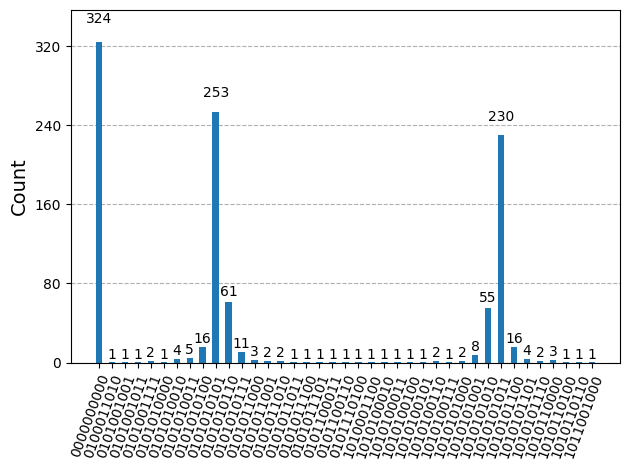

In [6]:
# Simulate the results
sim = AerSimulator()
tcircuit = transpile(circuit, sim)
result = sim.run(tcircuit).result()
counts = result.get_counts()
print(counts)
plot_histogram(counts)

In [7]:
# Post-processing to find the shuffling period
counts_int = {int(k, 2): v for k, v in counts.items() if int(k, 2)!=0}
sorted_counts = sorted(counts_int.items(), key=lambda x: -x[1])
print(sorted_counts[:5])
possible_periods = []
for y, c in sorted_counts[:5]:
    frac = Fraction(y, 2**n_control_qubits).limit_denominator(N)
    possible_periods.append(frac.denominator)
    print(frac)
print("Most probable period = ", max(set(possible_periods), key=possible_periods.count))

[(341, 253), (683, 230), (342, 61), (682, 55), (684, 16)]
1/3
2/3
1/3
2/3
2/3
Most probable period =  3
